In [1]:
!pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ReLU(preactivation: np.ndarray):
    activation = np.clip(preactivation, a_min=0, a_max=np.inf)
    return activation

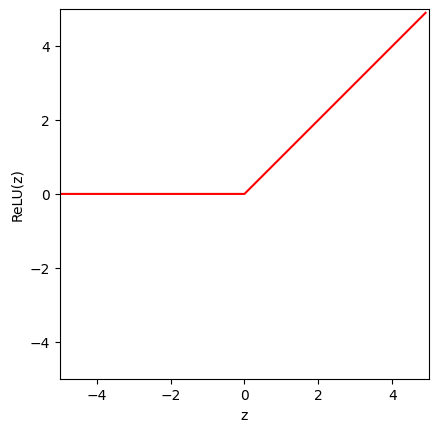

In [3]:
# synthetic inputs
z = np.arange(-5, 5, 0.1)
ReLU_z = ReLU(z)

# plot
fix, ax = plt.subplots()
ax.plot(z, ReLU_z, 'r-')
ax.set_xlim([-5, 5]); ax.set_ylim([-5, 5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU(z)')
ax.set_aspect('equal')
plt.show()

In [19]:
# shallow network: 1 input, 1 output, 3 hidden units
def shallow_1_1_3(x: float,
                    activation_fn: callable,
                    phi_0: float,
                    phi_1: float,
                    phi_2: float,
                    phi_3: float,
                    theta_10: float,
                    theta_11: float,
                    theta_20: float,
                    theta_21: float,
                    theta_30: float,
                    theta_31: float):
    pre_1 = theta_10 + theta_11 * x
    pre_2 = theta_20 + theta_21 * x
    pre_3 = theta_30 + theta_31 * x

    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    w_act_1 = phi_1 * act_1
    w_act_2 = phi_2 * act_2
    w_act_3 = phi_3 * act_3

    y = phi_0 + w_act_1 + w_act_2 + w_act_3
    return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [35]:
# plot NN
# assume: x [0, 1], y [-1, 1]
# if plt_all =  True, the intermediate stages are plotted too
def plot_neural(x,
                y,
                pre_1,
                pre_2,
                pre_3,
                act_1,
                act_2,
                act_3,
                w_act_1,
                w_act_2,
                w_act_3,
                plot_all: bool=False,
                x_data=None,
                y_data=None):
    if plot_all:
        fig, ax = plt.subplots(3, 3)
        fig.set_size_inches(16, 16)
        fig.tight_layout(pad=3.0)
        ax[0, 0].plot(x, pre_1, 'r-'); ax[0, 0].set_ylabel('preactivation'); ax[0, 0].plot(x, np.zeros(x.shape), '-')
        ax[0, 1].plot(x, pre_2, 'b-'); ax[0, 1].set_ylabel('preactivation'); ax[0, 1].plot(x, np.zeros(x.shape), '-')
        ax[0, 2].plot(x, pre_3, 'g-'); ax[0, 2].set_ylabel('preactivation'); ax[0, 2].plot(x, np.zeros(x.shape), '-')

        ax[1, 0].plot(x, act_1, 'r-'); ax[1, 0].set_ylabel('activation'); ax[1, 0].plot(x, np.zeros(x.shape), '-')
        ax[1, 1].plot(x, act_2, 'b-'); ax[1, 1].set_ylabel('activation'); ax[1, 1].plot(x, np.zeros(x.shape), '-')
        ax[1, 2].plot(x, act_3, 'g-'); ax[1, 2].set_ylabel('activation'); ax[1, 2].plot(x, np.zeros(x.shape), '-')

        ax[2, 0].plot(x, w_act_1, 'r-'); ax[2, 0].set_ylabel('weighted activation')
        ax[2, 1].plot(x, w_act_2, 'b-'); ax[2, 1].set_ylabel('weighted activation')
        ax[2, 2].plot(x, w_act_3, 'g-'); ax[2, 2].set_ylabel('weighted activation')

        for plot_y in range(3):
            for plot_x in range(3):
                ax[plot_y, plot_x].set_xlim([0, 1]); ax[plot_x, plot_y].set_ylim([-1, 1])
                ax[plot_y, plot_x].set_aspect(0.4)
            ax[2, plot_y].set_xlabel('input x')
        plt.show()

    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_xlabel('input x'); ax.set_ylabel('output y')
    ax.set_xlim([0,1]); ax.set_ylim([-1,1])
    ax.set_aspect(0.4)
    if x_data is not None:
        ax.plot(x_data, y_data, 'mo')
        for i in range(len(x_data)):
            ax.plot(x_data[i], y_data[i],)
    plt.show()

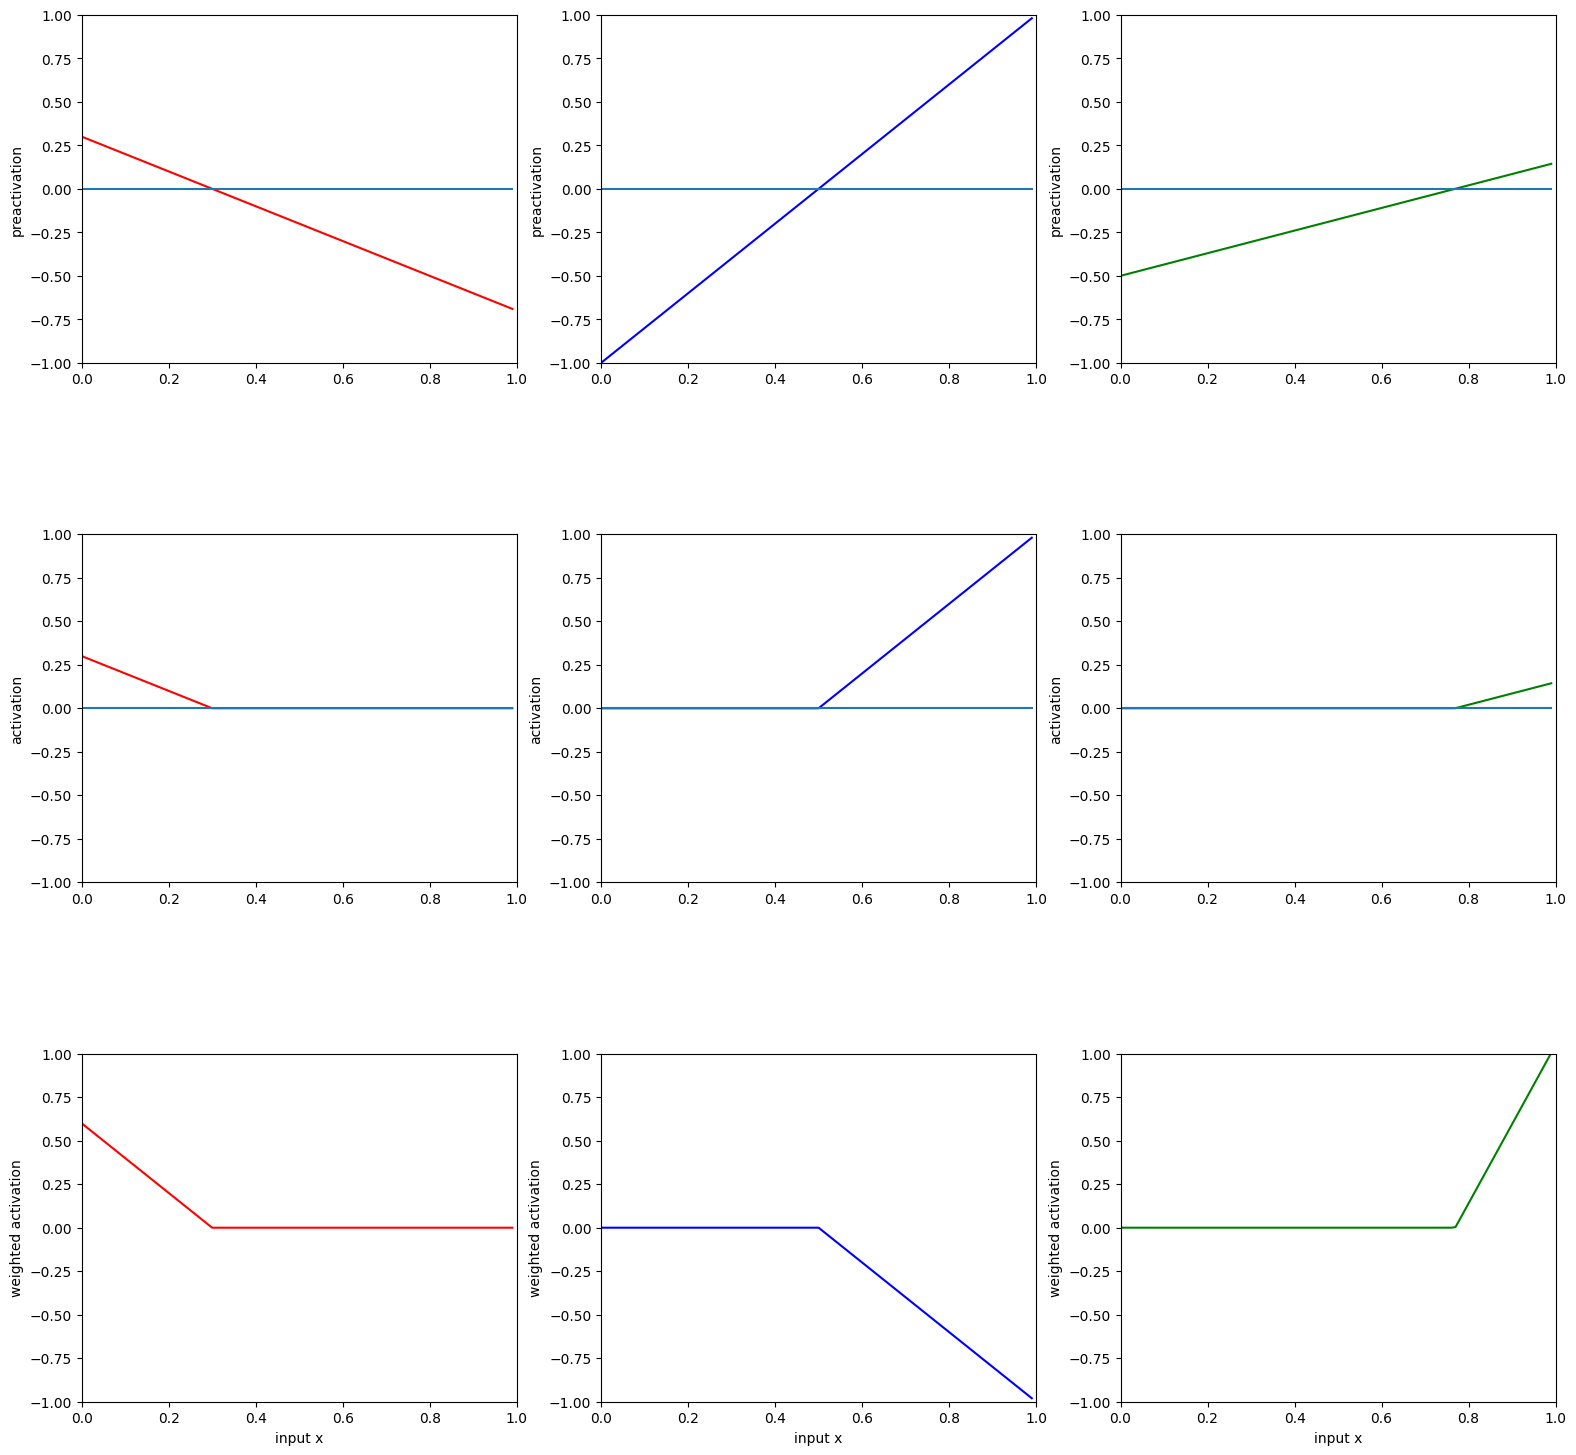

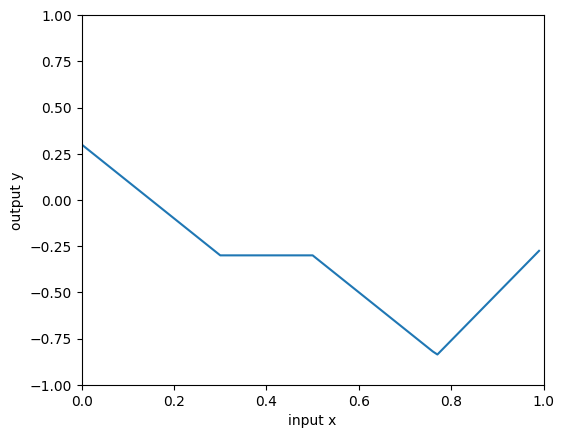

In [36]:
# run the NN
theta_10 = 0.3; theta_11 = -1.0
theta_20 = -1.0; theta_21 = 2.0
theta_30 = -0.5; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

x = np.arange(0, 1, 0.01)

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

In [37]:
def least_squares_loss(y_train, y_predict):
    loss = np.sum(np.power(y_train - y_predict, 2))
    return loss

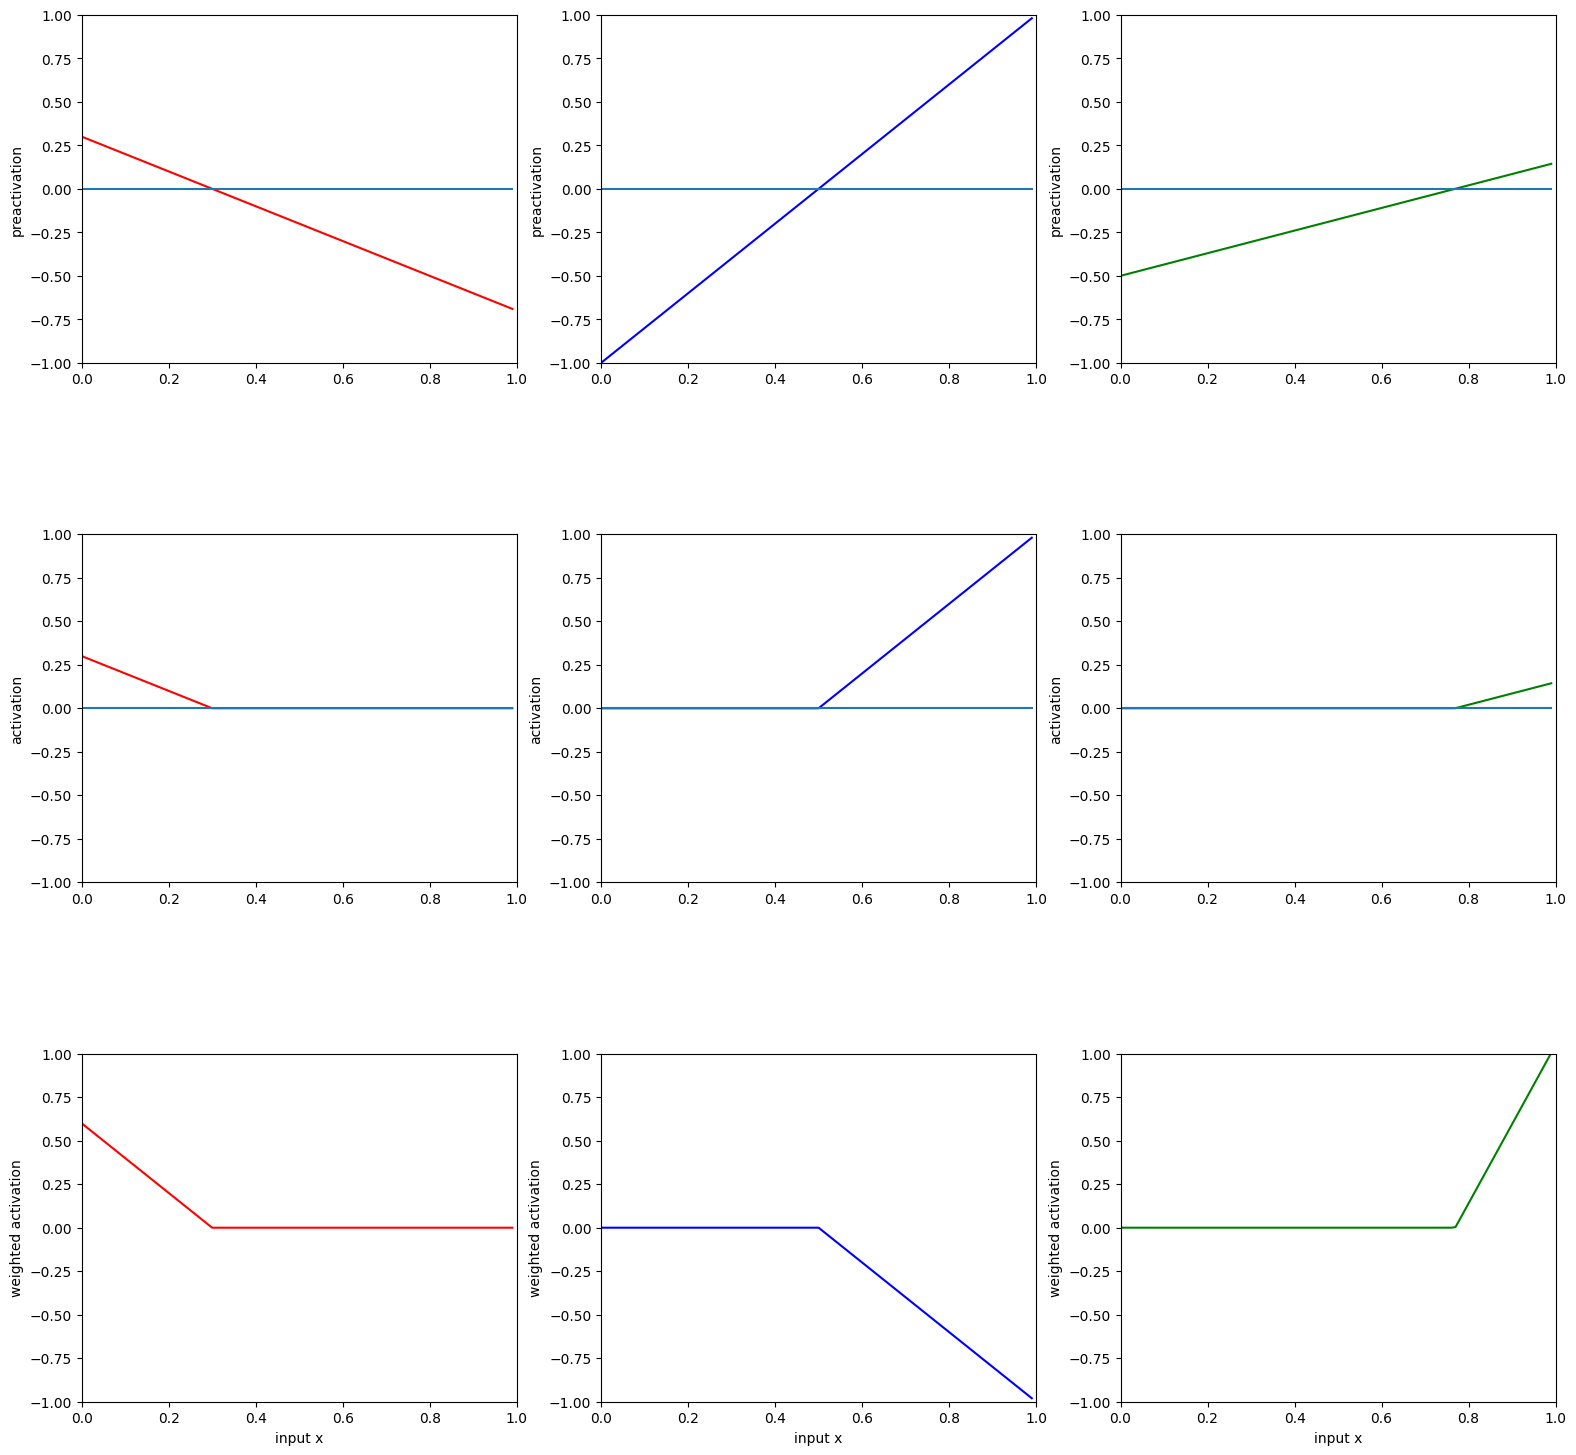

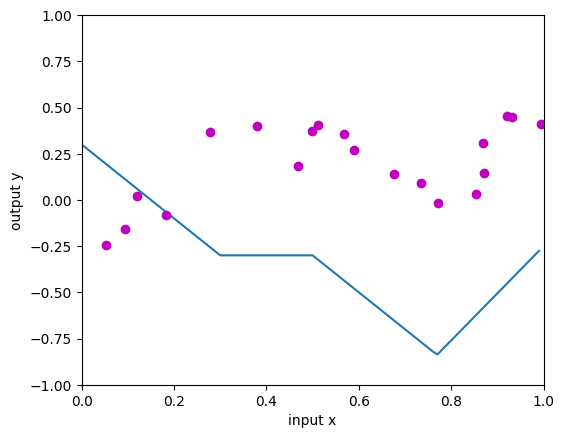

In [38]:
x = np.arange(0, 1, 0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

In [40]:
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
loss = least_squares_loss(y_train,y_predict)
print(f'Your Loss = {loss:3.3f}, True value = 9.385')

Your Loss = 9.385, True value = 9.385
